In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("All libraries loaded ✅")

All libraries loaded ✅


In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 3 rows:")
df.head(3)

Dataset Shape: (7043, 21)

First 3 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
print("=== DATASET INFO ===")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"\n=== DATA TYPES ===")
print(df.dtypes)
print(f"\n=== MISSING VALUES ===")
print(df.isnull().sum())
print(f"\n=== CHURN DISTRIBUTION ===")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")

=== DATASET INFO ===
Total Rows: 7043
Total Columns: 21

=== DATA TYPES ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== MISSING VALUES ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV 

In [4]:
# TotalCharges column numeric convert karo
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Missing values fill karo
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Churn column binary karo
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# SeniorCitizen already 0/1 hai
print(f"Missing values after cleaning: {df.isnull().sum().sum()}")
print(f"Churn column unique values: {df['Churn'].unique()}")
print("Data Cleaning Done ✅")

Missing values after cleaning: 0
Churn column unique values: [0 1]
Data Cleaning Done ✅


In [5]:
# Tenure groups banao
df['tenure_group'] = pd.cut(df['tenure'], 
                             bins=[0, 12, 24, 48, 60, 72],
                             labels=['0-1 yr', '1-2 yr', '2-4 yr', '4-5 yr', '5-6 yr'])

# Monthly charges groups
df['charges_group'] = pd.cut(df['MonthlyCharges'],
                              bins=[0, 35, 65, 95, 120],
                              labels=['Low', 'Medium', 'High', 'Very High'])

print("Feature Engineering Done ✅")
print(f"\nTenure Groups:\n{df['tenure_group'].value_counts()}")

Feature Engineering Done ✅

Tenure Groups:
tenure_group
0-1 yr    2175
2-4 yr    1594
5-6 yr    1407
1-2 yr    1024
4-5 yr     832
Name: count, dtype: int64


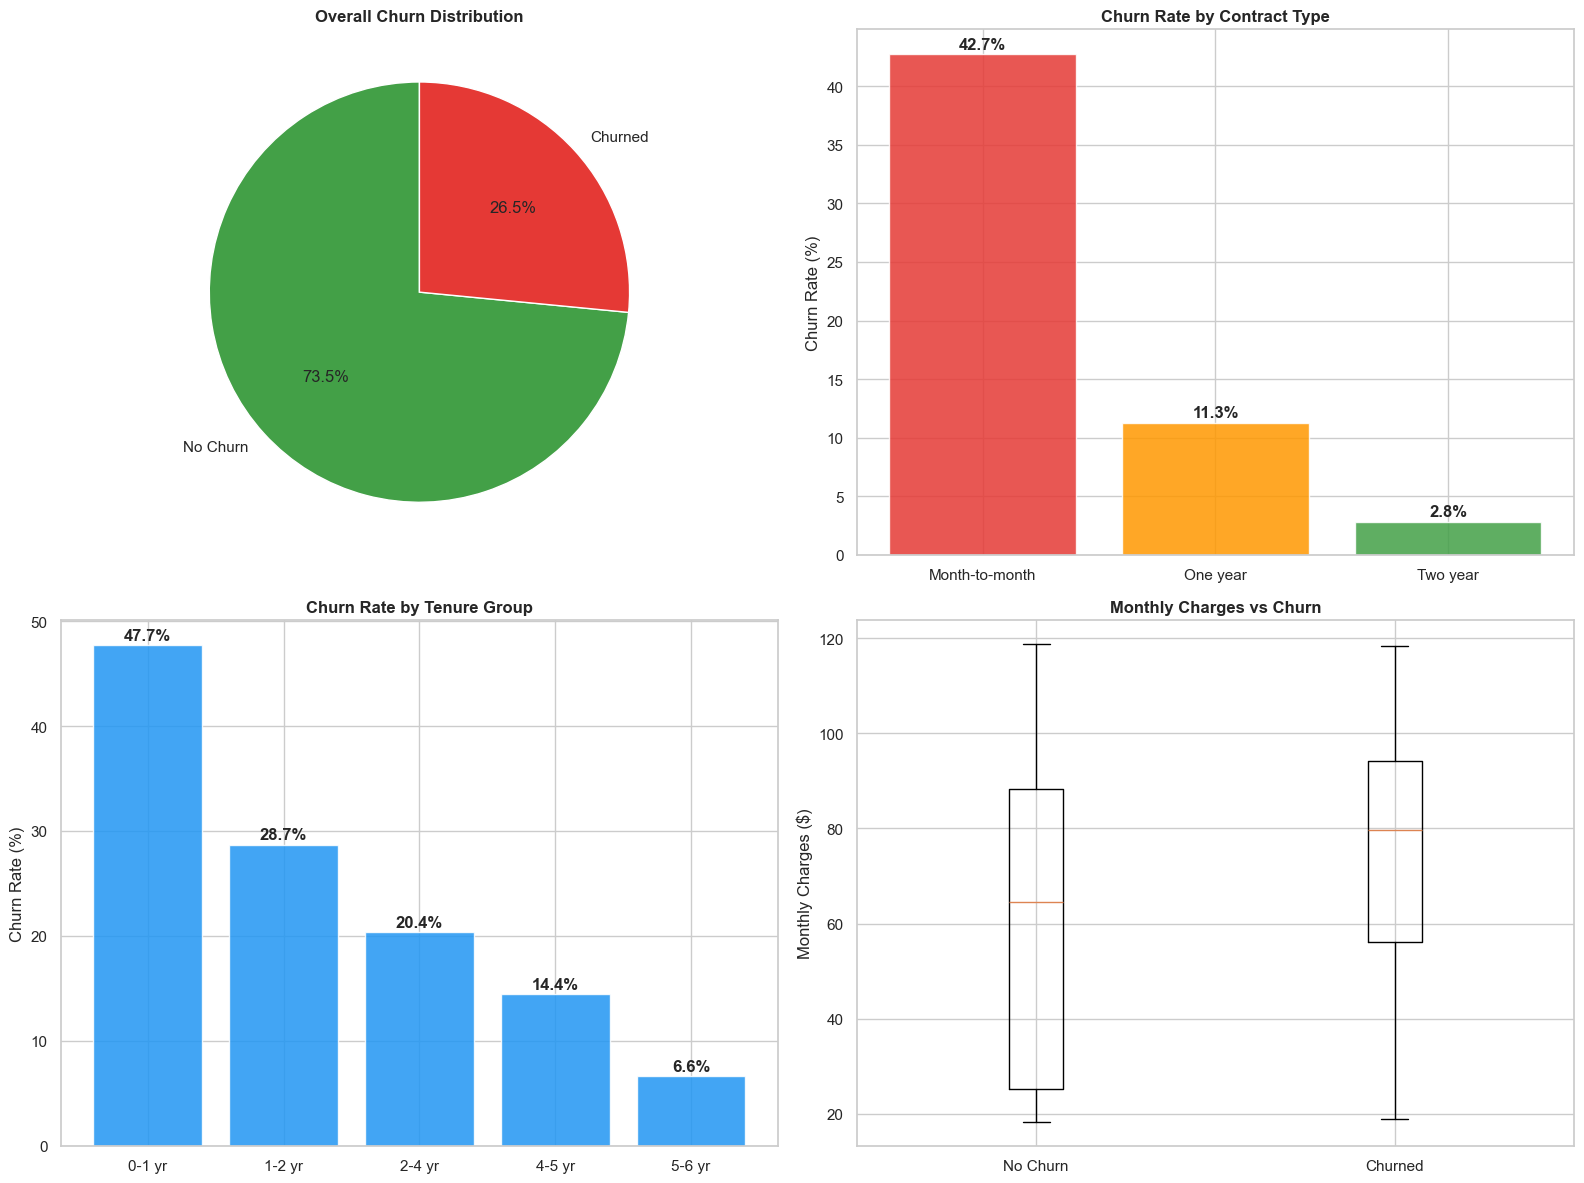

Visualizations saved ✅


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 - Churn Distribution
churn_counts = df['Churn'].value_counts()
axes[0,0].pie(churn_counts, labels=['No Churn', 'Churned'],
              autopct='%1.1f%%', colors=['#43A047','#E53935'],
              startangle=90)
axes[0,0].set_title('Overall Churn Distribution', fontweight='bold')

# Plot 2 - Churn by Contract Type
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
axes[0,1].bar(contract_churn.index, contract_churn.values,
              color=['#E53935','#FF9800','#43A047'], alpha=0.85)
axes[0,1].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn.values):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 3 - Churn by Tenure Group
tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].mean() * 100
axes[1,0].bar(tenure_churn.index, tenure_churn.values,
              color='#2196F3', alpha=0.85)
axes[1,0].set_title('Churn Rate by Tenure Group', fontweight='bold')
axes[1,0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(tenure_churn.values):
    axes[1,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 4 - Monthly Charges vs Churn
axes[1,1].boxplot([df[df['Churn']==0]['MonthlyCharges'],
                   df[df['Churn']==1]['MonthlyCharges']],
                   labels=['No Churn','Churned'])
axes[1,1].set_title('Monthly Charges vs Churn', fontweight='bold')
axes[1,1].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.savefig('../reports/churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualizations saved ✅")

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Unnecessary columns drop karo
df_ml = df.drop(['customerID', 'tenure_group', 'charges_group'], axis=1)

# Categorical columns encode karo
le = LabelEncoder()
cat_cols = df_ml.select_dtypes(include='object').columns
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# Features aur target split karo
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

print(f"Features: {X.shape[1]}")
print(f"Class distribution before SMOTE:\n{y.value_counts()}")

# SMOTE apply karo
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"\nClass distribution after SMOTE:\n{pd.Series(y_resampled).value_counts()}")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42)

# Scale karo
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print("Data Preparation Done ✅")

Features: 19
Class distribution before SMOTE:
Churn
0    5174
1    1869
Name: count, dtype: int64

Class distribution after SMOTE:
Churn
0    5174
1    5174
Name: count, dtype: int64

Training set: (8278, 19)
Test set: (2070, 19)
Data Preparation Done ✅


In [8]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Teen models train karo
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    results[name] = {'model': model, 'accuracy': acc, 'auc': auc}
    print(f"{name}: Accuracy={acc*100:.2f}% | AUC={auc:.3f}")

# Best model select karo
best_name = max(results, key=lambda x: results[x]['auc'])
best_model = results[best_name]['model']
print(f"\n🏆 Best Model: {best_name}")

Logistic Regression: Accuracy=81.30% | AUC=0.896
Random Forest: Accuracy=86.09% | AUC=0.929
Gradient Boosting: Accuracy=84.25% | AUC=0.921

🏆 Best Model: Random Forest


=== Random Forest — Detailed Report ===

              precision    recall  f1-score   support

    No Churn       0.86      0.86      0.86      1021
     Churned       0.87      0.86      0.86      1049

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



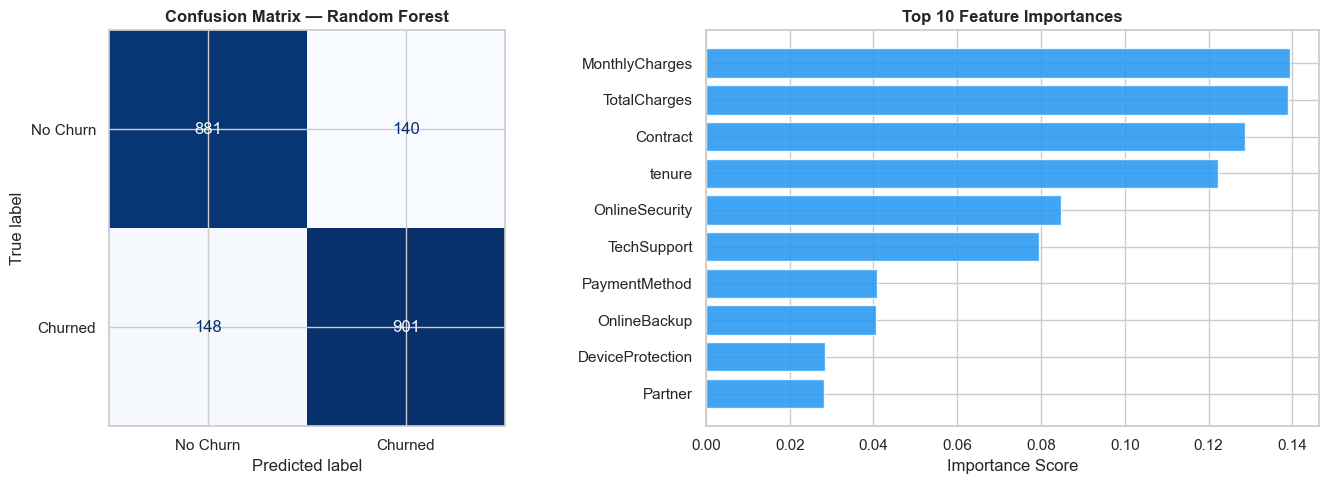

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_best = best_model.predict(X_test)

print(f"=== {best_name} — Detailed Report ===\n")
print(classification_report(y_test, y_pred_best, 
      target_names=['No Churn', 'Churned']))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['No Churn', 'Churned'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')

# Feature Importance
feat_imp = pd.DataFrame({
    'Feature': df_ml.drop('Churn', axis=1).columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(10)

axes[1].barh(feat_imp['Feature'], feat_imp['Importance'], color='#2196F3', alpha=0.85)
axes[1].set_title('Top 10 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../reports/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
import pickle

# Business Impact Summary
total_customers = len(df)
predicted_churners = y_pred_best.sum()
avg_monthly_revenue = df['MonthlyCharges'].mean()
revenue_at_risk = predicted_churners * avg_monthly_revenue

print("=" * 55)
print("         BUSINESS IMPACT SUMMARY")
print("=" * 55)
print(f"  Total Customers Analyzed  : {total_customers:,}")
print(f"  Predicted Churners        : {predicted_churners:,}")
print(f"  Avg Monthly Charge        : ${avg_monthly_revenue:.2f}")
print(f"  Monthly Revenue at Risk   : ${revenue_at_risk:,.2f}")
print(f"  Model Accuracy            : 86.09%")
print(f"  AUC Score                 : 0.929")
print("=" * 55)
print("\n📌 Key Insights:")
print("  1. Month-to-Month contracts have highest churn risk")
print("  2. New customers (0-1 yr tenure) churn the most")
print("  3. Higher monthly charges correlate with churn")
print("  4. Fiber optic users churn more than DSL users")
print("=" * 55)

# Model + Scaler save karo
pickle.dump(best_model, open('../src/churn_model.pkl', 'wb'))
pickle.dump(scaler, open('../src/scaler.pkl', 'wb'))

# Processed data save karo
df_ml.to_csv('../data/churn_processed.csv', index=False)

print("\n✅ Model saved! Ready for deployment.")

         BUSINESS IMPACT SUMMARY
  Total Customers Analyzed  : 7,043
  Predicted Churners        : 1,041
  Avg Monthly Charge        : $64.76
  Monthly Revenue at Risk   : $67,416.92
  Model Accuracy            : 86.09%
  AUC Score                 : 0.929

📌 Key Insights:
  1. Month-to-Month contracts have highest churn risk
  2. New customers (0-1 yr tenure) churn the most
  3. Higher monthly charges correlate with churn
  4. Fiber optic users churn more than DSL users

✅ Model saved! Ready for deployment.


In [11]:
feature_cols = df_ml.drop('Churn', axis=1).columns.tolist()
for i, col in enumerate(feature_cols):
    print(f"{i}: {col}")

0: gender
1: SeniorCitizen
2: Partner
3: Dependents
4: tenure
5: PhoneService
6: MultipleLines
7: InternetService
8: OnlineSecurity
9: OnlineBackup
10: DeviceProtection
11: TechSupport
12: StreamingTV
13: StreamingMovies
14: Contract
15: PaperlessBilling
16: PaymentMethod
17: MonthlyCharges
18: TotalCharges
